# Phishing Email Detection with BERT
## Notebook 03 – Robustness Training with TextAttack

This notebook evaluates and improves the robustness of the BERT classifier using adversarial text attacks.


### Notebook objectives

- Load the trained BERT model and tokenizer.
- Prepare the dataset for adversarial evaluation.
- Configure and run multiple TextAttack recipes.
- Log successful attacks to CSV for later analysis.
- Build an adversarial-augmented training set.


### 1. Imports and configuration

Import TextAttack, HuggingFace, and utility libraries and configure paths.


In [1]:
import random
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import optuna
import textattack

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from IPython.display import display

from transformers import (
    AutoTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

from textattack.datasets import Dataset as TA_Dataset
from textattack.models.wrappers import HuggingFaceModelWrapper
from textattack.attack_recipes import TextFoolerJin2019, BAEGarg2019

# Set seed and prepare directories
SEED = 2025
ANALYSIS_DIR = Path("../analysis/text_attack")
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


2025-12-02 09:37:28.988833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 09:37:29.402617: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 09:37:31.210417: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/nmd/projects/phishing-detector/venv/lib/python3.12/site-packages/jieba/_compat.py:18:

### 2. Load Optuna hyperparameters

Retrieve tuned hyperparameters from SQLite if available; otherwise use fallback defaults.


In [2]:

best_hyperparameters = {
    "learning_rate": 2e-5,
    "num_train_epochs": 3,
    "per_device_train_batch_size": 16,
    "weight_decay": 0.01,
    "dropout": 0.1,
}

optuna_database_path = Path.cwd() / "tuning_checkpoints" / "bert_tuning_full.db"
optuna_study_name = "bert_tuning_full"

try:
    loaded_study = optuna.load_study(
        study_name=optuna_study_name,
        storage=f"sqlite:///{optuna_database_path}",
    )
    best_hyperparameters.update(loaded_study.best_trial.params)
    print("Loaded best hyperparameters from bert_tuning_full.db")
except Exception:
    print("Optuna study not found, using default hyperparameters.")

best_hyperparameters["num_train_epochs"] = int(best_hyperparameters.get("num_train_epochs", 3))
best_hyperparameters["per_device_train_batch_size"] = int(best_hyperparameters.get("per_device_train_batch_size", 16))
best_hyperparameters["learning_rate"] = float(best_hyperparameters.get("learning_rate", 2e-5))
best_hyperparameters["weight_decay"] = float(best_hyperparameters.get("weight_decay", 0.01))
best_hyperparameters["dropout"] = float(best_hyperparameters.get("dropout", 0.1))

print("\nFinal hyperparameters in use:")
for key, value in best_hyperparameters.items():
    print(f"  {key}: {value}")


Loaded best hyperparameters from bert_tuning_full.db

Final hyperparameters in use:
  learning_rate: 1.826222907426669e-05
  num_train_epochs: 5
  per_device_train_batch_size: 16
  weight_decay: 0.10631544814686143
  dropout: 0.3098949027144738


### 3. Initialize tokenizer and tuned BERT model

Load the model (checkpoint or pretrained) and apply tuned dropout settings.


In [3]:

model_checkpoint_path = Path("../models") / "saved_model"
model_name_or_path = str(model_checkpoint_path) if model_checkpoint_path.exists() else "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)
model = BertForSequenceClassification.from_pretrained(
    model_name_or_path,
    num_labels=2,
    hidden_dropout_prob=best_hyperparameters["dropout"],
    attention_probs_dropout_prob=best_hyperparameters["dropout"],
)
if torch.cuda.is_available():
    model = model.to("cuda")


### 4. Load dataset splits from 02 notebook

Read train/val/test CSV files and extract texts and labels.


In [4]:

splits_dir_path = Path("../data") / "splits"
train_csv_path = splits_dir_path / "train.csv"
val_csv_path = splits_dir_path / "val.csv"
test_csv_path = splits_dir_path / "test.csv"

train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print("Loaded precomputed splits from data/splits/.")

train_texts = train_df["text"].astype(str).tolist()
train_labels = train_df["label"].astype(int).tolist()
val_texts = val_df["text"].astype(str).tolist()
val_labels = val_df["label"].astype(int).tolist()
test_texts = test_df["text"].astype(str).tolist()
test_labels = test_df["label"].astype(int).tolist()

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")


Loaded precomputed splits from data/splits/.
Train: 143810 | Val: 15979 | Test: 39948


### 5. Build balanced correctly-classified subset for TextAttack

Identify correctly predicted samples and select a balanced subset for adversarial attacks.


In [5]:

candidate_size = 2000
batch_size = 32
candidate_texts = train_texts[:candidate_size]
candidate_labels = train_labels[:candidate_size]
model_device = next(model.parameters()).device

model.eval()

correct_texts = []
correct_labels = []

for start_idx in range(0, len(candidate_texts), batch_size):
    batch_texts = candidate_texts[start_idx:start_idx + batch_size]
    encodings = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt",
    )
    encodings = {k: v.to(model_device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        preds = logits.argmax(dim=1).cpu().numpy().tolist()

    true_batch_labels = candidate_labels[start_idx:start_idx + batch_size]

    for text_value, true_label_value, pred_value in zip(batch_texts, true_batch_labels, preds):
        if int(true_label_value) == int(pred_value):
            correct_texts.append(text_value)
            correct_labels.append(int(true_label_value))

print("Candidate slice distribution:", Counter(candidate_labels))
print("Correctly classified distribution:", Counter(correct_labels))

N_ATTACK = 500
per_class = N_ATTACK // 2

correct_by_label = {0: [], 1: []}
for text_value, lbl in zip(correct_texts, correct_labels):
    correct_by_label[int(lbl)].append((text_value, int(lbl)))

avail_pos = len(correct_by_label[1])
avail_neg = len(correct_by_label[0])
print("Available correctly classified per class - pos:", avail_pos, "neg:", avail_neg)

sampled_pos = random.sample(correct_by_label[1], min(per_class, avail_pos))
sampled_neg = random.sample(correct_by_label[0], min(per_class, avail_neg))

sampled_pairs = sampled_pos + sampled_neg

attack_texts_subset = [t for t, _ in sampled_pairs]
attack_labels_subset = [l for _, l in sampled_pairs]

textattack_examples = [(t, l) for t, l in zip(attack_texts_subset, attack_labels_subset)]
ta_dataset = TA_Dataset(textattack_examples)

print("Prepared TextAttack dataset size:", len(textattack_examples))
print("Attack label counts:", Counter([l for _, l in textattack_examples]))


Candidate slice distribution: Counter({0: 1088, 1: 912})
Correctly classified distribution: Counter({0: 1083, 1: 900})
Available correctly classified per class - pos: 900 neg: 1083
Prepared TextAttack dataset size: 500
Attack label counts: Counter({1: 250, 0: 250})


### 6. Initialize TextAttack recipes

Create the HuggingFace wrapper and load the chosen attack algorithms.


In [6]:

model_wrapper = HuggingFaceModelWrapper(model, tokenizer)
available_recipes = []
available_recipes.append(("TextFooler", TextFoolerJin2019.build(model_wrapper)))
available_recipes.append(("BAE", BAEGarg2019.build(model_wrapper)))

print("Configured recipes:", [name for name, _ in available_recipes])


textattack: Unknown if model of class <class 'transformers.models.bert.modeling_bert.BertForSequenceClassification'> compatible with goal function <class 'textattack.goal_functions.classification.untargeted_classification.UntargetedClassification'>.
Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
textattack: Unknown if model of class <class 'transformers.mode

Configured recipes: ['TextFooler', 'BAE']


### 7. Configure and execute TextAttack recipes

Configure TextAttack arguments such as the number of examples and logging paths.

Run each attack algorithm on the subset dataset and save detailed results to CSV.


In [7]:

# Run a TextAttack recipe on the dataset and log all results to CSV
def run_attack_recipe(recipe_name, recipe_object, ta_dataset):
    attack_args = textattack.AttackArgs(
        num_examples=len(ta_dataset),
        log_to_csv=str(ANALYSIS_DIR / f"textattack_{recipe_name}.csv"),
        checkpoint_interval=50,
        parallel=False,
        silent=True,
    )
    attacker = textattack.Attacker(
        recipe_object,
        ta_dataset,
        attack_args=attack_args,
    )
    for i, _ in enumerate(attacker.attack_dataset()):
        try:
            pass
        except Exception as e:
            if i < len(ta_dataset):
                bad_example = ta_dataset[i]
                bad_text = getattr(bad_example, "text", "<no-text-attr>")
            else:
                bad_text = "<unknown>"
            print(
                f"[WARN] Skipping example #{i} ({bad_text[:60]}...): {e}"
            )
            continue

for recipe_name_value, recipe_object_value in available_recipes:
    try:
        run_attack_recipe(recipe_name_value, recipe_object_value, ta_dataset)
    except Exception as attack_error:
        print(f"[ERROR] Recipe '{recipe_name_value}' failed entirely:", attack_error)


  0%|                                                                                           | 0/500 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1764655702.296400     843 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3849 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9
[Succeeded / Failed / Skipped / Total] 1 / 0 / 0 / 1:   0%|                         | 1/500 [02:28<20:33:20, 148.30s/it]

--------------------------------------------- Result 1 ---------------------------------------------
[[1 (100%)]] --> [[0 (96%)]]

100% [[money]] back [[guarantee]].[[try]] it [[today]] - you have nothing to lose, just a lot to [[gain]]! "ever since i [[started]] on your herbal supplement, sharon says [[sex]] is [[so]] [[much]] more [[pleasurable]] for her, and she [[comes]] [[much]] more easily".david, [[florida]], usa [[[url]]]

100% [[monies]] back [[gage]].[[wish]] it [[friday]] - you have nothing to lose, just a lot to [[soars]]! "ever since i [[commencement]] on your herbal supplement, sharon says [[coitus]] is [[tad]] [[noticeably]] more [[amusing]] for her, and she [[occurs]] [[noticeably]] more easily".david, [[fla]], usa [[[http]]]


[Succeeded / Failed / Skipped / Total] 2 / 0 / 0 / 2:   0%|                          | 2/500 [02:30<10:24:26, 75.23s/it]

--------------------------------------------- Result 2 ---------------------------------------------
[[1 (100%)]] --> [[0 (59%)]]

more [[massive]] [[love]] luger the best way to please your lassie like a [[real]] casanova, is to get your love gun [[bigger]]! give yourself an opportunity to become a real [[man]]! [[[url]]] any of the financial markets around the world-in contrast to conventionalfluctuating exchange rate system [[speculative]] transactions assume progressivelyhaving exploited the chaos in western [[europe]], [[george]] soros then

more [[forklift]] [[dear]] luger the best way to please your lassie like a [[actual]] casanova, is to get your love gun [[big]]! give yourself an opportunity to become a real [[buddy]]! [[[http]]] any of the financial markets around the world-in contrast to conventionalfluctuating exchange rate system [[notional]] transactions assume progressivelyhaving exploited the chaos in western [[union]], [[georgie]] soros then


[Succeeded / Failed / Skipped / Total] 3 / 0 / 0 / 3:   1%|▏                          | 3/500 [03:27<9:32:24, 69.10s/it]

...

--------------------------------------------- Result 499 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

re:[r] parsing data with an uneven number of delimiters try:read.table(textconnection(l1), sep = "/", fill = true) on 5/3/07, kevin burke wrote:> i have a list of data that is delimited by a/and, as long as there is an equal number of delimiters, i can parse the data and put it into a data frame:> > > t1 > t2 > t3 > t3 > c..a....a....a..c..b....bb....bbb..c..ccc....cc....c..> 1 a b ccc > 2 a bb cc > 3 a bbb c > > however, if i don't have an equal number of delimiters, this technique doesn't work:> > > l1 > l2 > l3 error in data.frame(c("a", "a", "a"), c("b", "bb", "bbb"), c("cc", "c":> arguments imply differing number of rows:3, 2 > > is there an easy way to get this into a data frame with na's (or something else) where the missing data would be? > > thanks in advance.> > kevin burke > > ______________________________________________ > r-help@stat.math.e

[Succeeded / Failed / Skipped / Total] 83 / 417 / 0 / 500: 100%|████████████████████| 500/500 [2:18:48<00:00, 16.66s/it]

--------------------------------------------- Result 500 ---------------------------------------------
[[0 (100%)]] --> [[[FAILED]]]

intro to natural gas/natural gas transactions may 15-17 dallas euci newsletter in-depth introduction to the natural gas industry natural gas transactions, trading & origination for non-traders may 15-17, 2007 dallas, texas click here to download a complete conference brochure click here for a complete listing of upcoming conferences overview in-depth introduction to the natural gas industry may 15 – 16, 2007 this in-depth introductory course is designed for those with limited knowledge of the natural gas industry.it provides an overview of the industry focusing on fundamentals of this form of energy, its history, and the typical assets, markets, and regulatory systems it takes to produce and deliver natural gas to its end uses.specifi c examples and actual market data are used to illustrate basic principles and ideas.this seminar uses several approaches 

[Succeeded / Failed / Skipped / Total] 83 / 417 / 0 / 500: 100%|████████████████████| 500/500 [2:18:48<00:00, 16.66s/it]


+-------------------------------+--------+
| Attack Results                |        |
+-------------------------------+--------+
| Number of successful attacks: | 83     |
| Number of failed attacks:     | 417    |
| Number of skipped attacks:    | 0      |
| Original accuracy:            | 100.0% |
| Accuracy under attack:        | 83.4%  |
| Attack success rate:          | 16.6%  |
| Average perturbed word %:     | 11.82% |
| Average num. words per input: | 221.59 |
| Avg num queries:              | 517.32 |
+-------------------------------+--------+


### 8. Merge attack logs and inspect successful vs. failed examples

Combine TextAttack CSV outputs, label successes, save filtered files, and preview sample rows.


In [5]:

merged_path = ANALYSIS_DIR / "textattack_merged.csv"
merged_success_path = ANALYSIS_DIR / "textattack_success.csv"
merged_failed_path = ANALYSIS_DIR / "textattack_failed.csv"

dfs = []
for p in [ANALYSIS_DIR / "textattack_TextFooler.csv", ANALYSIS_DIR / "textattack_BAE.csv"]:
    if p.exists():
        df = pd.read_csv(p)
        df["__source"] = p.stem
        dfs.append(df)
    else:
        print(f"WARNING: not found: {p}")

if not dfs:
    raise FileNotFoundError("No TextAttack CSV logs found to merge.")

df_attacks = pd.concat(dfs, ignore_index=True)
print(f"Merged rows: {len(df_attacks)}")

orig_col = "original_text"
pert_col = "perturbed_text"
result_col = "result_type"
orig_out_col = "original_output"
pert_out_col = "perturbed_output"

if result_col in df_attacks.columns:
    c = df_attacks[result_col].astype(str).str.strip().str.lower()
    is_success = c.eq("successful")
else:
    is_success = pd.Series([False] * len(df_attacks), index=df_attacks.index)

df_attacks["is_success"] = is_success.astype(bool)

print(" total :", len(df_attacks))
print(" success:", int(df_attacks["is_success"].sum()))
print(" failed :", int((~df_attacks["is_success"]).sum()))

df_attacks.to_csv(merged_path, index=False, encoding="utf-8")
df_attacks[df_attacks["is_success"]].to_csv(merged_success_path, index=False, encoding="utf-8")
df_attacks[~df_attacks["is_success"]].to_csv(merged_failed_path, index=False, encoding="utf-8")

print(f"Saved merged to   : {merged_path}")
print(f"Saved success rows to : {merged_success_path}")
print(f"Saved failed rows to  : {merged_failed_path}")

df_success = df_attacks[df_attacks["is_success"]].copy()
df_failed = df_attacks[~df_attacks["is_success"]].copy()

display_cols = [col for col in [orig_col, pert_col, orig_out_col, pert_out_col, result_col, "__source"] if col in df_attacks.columns]

print("\nSAMPLE successful rows (first 5):")
display(df_success[display_cols].head(5))

print("\nSAMPLE failed rows (first 5):")
display(df_failed[display_cols].head(5))


Merged rows: 1000
 total : 1000
 success: 503
 failed : 497
Saved merged to   : ../analysis/text_attack/textattack_merged.csv
Saved success rows to : ../analysis/text_attack/textattack_success.csv
Saved failed rows to  : ../analysis/text_attack/textattack_failed.csv

SAMPLE successful rows (first 5):


,original_text,perturbed_text,original_output,perturbed_output,result_type,__source
0,100% [[money]] back [[guarantee]].[[try]] it [...,100% [[monies]] back [[gage]].[[wish]] it [[fr...,1,0,Successful,textattack_TextFooler
1,more [[massive]] [[love]] luger the best way t...,more [[forklift]] [[dear]] luger the best way ...,1,0,Successful,textattack_TextFooler
2,[[business]] [[transaction]].greetings from mr...,[[firms]] [[transactions]].greetings from mr.[...,1,0,Successful,textattack_TextFooler
3,[[full]] [[cd]] milla jovovich #rsmlkpclara mo...,[[ensemble]] [[dc]] milla jovovich #rsmlkpclar...,1,0,Successful,textattack_TextFooler
4,nsw lotteries corporation nsw lotteries corpor...,nsw lotteries corporation nsw lotteries corpor...,1,0,Successful,textattack_TextFooler



SAMPLE failed rows (first 5):


,original_text,perturbed_text,original_output,perturbed_output,result_type,__source
28,�� ������� ����ǵ� [[loan]] (���ͳ����� �ְ� 5000...,�� ������� ����ǵ� [[lending]] (���ͳ����� �ְ� 5...,1,1,Failed,textattack_TextFooler
38,productsgenericsspecialprices canadianuslicens...,productsgenericsspecialprices canadianuslicens...,1,1,Failed,textattack_TextFooler
42,�� ���� �¶��� 4���� �л����� �ڷ� �ޱ� ! ��������...,�� ���� �¶��� 4���� �л����� �ڷ� �ޱ� ! ��������...,1,1,Failed,textattack_TextFooler
43,k2 ���ȭ ���嵵 ���ݿ� �帳�θ�.(�� ��갥���� �ų���?) m...,k2 ���ȭ ���嵵 ���ݿ� �帳�θ�.(�� ��갥���� �ų���?) m...,1,1,Failed,textattack_TextFooler
46,-����- 30���� ��������� �����ͽ� ���� ȯ���ϰ� �ص...,-����- 30���� ��������� �����ͽ� ���� ȯ���ϰ� �ص...,1,1,Failed,textattack_TextFooler


### 9. Retrained using augment training set with successful adversarial examples

Append perturbed TextAttack samples to the original training set and shuffle to create an augmented dataset.


In [6]:

success_csv_path = ANALYSIS_DIR / "textattack_success.csv"
merged_csv_path = ANALYSIS_DIR / "textattack_merged.csv"

augmented_train_texts = list(train_texts)
augmented_train_labels = list(train_labels)

print("Original training set size:", len(augmented_train_texts))

adv_texts = []
adv_labels = []

if success_csv_path.exists():
    df_succ = pd.read_csv(success_csv_path)
    if "is_success" in df_succ.columns:
        df_succ = df_succ[df_succ["is_success"] == True]
    if "perturbed_text" in df_succ.columns and df_succ["perturbed_text"].astype(str).str.len().gt(0).any():
        adv_texts = df_succ["perturbed_text"].astype(str).tolist()
        if "ground_truth_output" in df_succ.columns:
            adv_labels = df_succ["ground_truth_output"].astype(int).tolist()
        else:
            adv_labels = df_succ["original_output"].astype(int).tolist()
        print(f"Loaded {len(adv_texts)} adversarial samples from success CSV.")
else:
    print("Cannot find the Successful Attacked Cases.")

if len(adv_texts) == len(adv_labels) and len(adv_texts) > 0:
    augmented_train_texts.extend(adv_texts)
    augmented_train_labels.extend(adv_labels)
    print("Appended adversarial samples to training set.")
elif len(adv_texts) != len(adv_labels):
    print("WARNING: texts and labels length mismatch, skipping append.")
else:
    print("No adversarial samples added.")

combined = list(zip(augmented_train_texts, augmented_train_labels))
random.shuffle(combined)
augmented_train_texts, augmented_train_labels = zip(*combined)
augmented_train_texts = list(augmented_train_texts)
augmented_train_labels = list(augmented_train_labels)

print("Final augmented training set size:", len(augmented_train_texts))
print("Validation set size:", len(val_texts))


Original training set size: 143810
Loaded 503 adversarial samples from success CSV.
Appended adversarial samples to training set.
Final augmented training set size: 144313
Validation set size: 15979


### 10. Tokenize augmented and evaluation splits

Prepare tokenized inputs for the augmented training set, validation set, and test set.


In [7]:

aug_train_encodings = tokenizer(
    augmented_train_texts,
    truncation=True,
    padding=True,
    max_length=256,
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length=256,
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256,
)

print("Tokenized augmented train samples:", len(aug_train_encodings["input_ids"]))
print("Tokenized validation samples:", len(val_encodings["input_ids"]))


Tokenized augmented train samples: 144313
Tokenized validation samples: 15979


### 11. Create dataset wrappers for augmented, validation, and test sets

Build PyTorch `Dataset` objects for all splits using the custom `EmailDataset` class.


In [8]:

class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_dataset_aug = EmailDataset(aug_train_encodings, augmented_train_labels)
val_dataset = EmailDataset(val_encodings, val_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

print("Train dataset length:", len(train_dataset_aug))
print("Val dataset length:", len(val_dataset))
print("Test dataset length:", len(test_dataset))


Train dataset length: 144313
Val dataset length: 15979
Test dataset length: 39948


### 12. Metrics function

Compute accuracy, precision, recall, and F1 for model evaluation.


In [9]:

# Compute evaluation metrics such as accuracy, precision, recall and F1
def compute_metrics(eval_pred):

    if hasattr(eval_pred, "predictions"):
        logits = eval_pred.predictions
        labels = eval_pred.label_ids
    else:
        logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


### 13. Initialize tuned BERT model and Trainer

Set up TrainingArguments with the best hyperparameters and create a Trainer for 
fine-tuning on the augmented dataset.


In [10]:

tuned_dropout = float(best_hyperparameters.get("dropout", 0.1))

# Create a BERT model instance configured for TextAttack training
def model_init_textattack():
    return BertForSequenceClassification.from_pretrained(
        model_checkpoint_path,
        num_labels=2,
        hidden_dropout_prob=tuned_dropout,
        attention_probs_dropout_prob=tuned_dropout,
    )

training_args = TrainingArguments(
    output_dir=("results_textattack_augmented"),
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    learning_rate=float(best_hyperparameters["learning_rate"]),
    num_train_epochs=int(best_hyperparameters["num_train_epochs"]),
    per_device_train_batch_size=int(best_hyperparameters["per_device_train_batch_size"]),
    per_device_eval_batch_size=max(32, int(best_hyperparameters["per_device_train_batch_size"])),
    weight_decay=float(best_hyperparameters.get("weight_decay", 0.01)),
    logging_steps=200,
    seed=SEED,
    report_to=[],
)

trainer = Trainer(
    model_init=model_init_textattack,
    args=training_args,
    train_dataset=train_dataset_aug,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)


/tmp/ipykernel_4840/2720887886.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


### 14. Train and save augmented model

Fine-tune on augmented data and save the resulting model checkpoint.


In [11]:

train_output = trainer.train()

FINAL_DIR = Path("../models/saved_model_augmented")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(FINAL_DIR))
tokenizer.save_pretrained(str(FINAL_DIR))

print("Saved augmented model and tokenizer to:", FINAL_DIR)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.027900,0.071342,0.987358,0.995853,0.976681,0.986174
2,0.022100,0.077925,0.986858,0.995711,0.975732,0.985620
3,0.014900,0.087515,0.987421,0.995991,0.976681,0.986241
4,0.003600,0.081203,0.988610,0.995864,0.979393,0.987560
5,0.010200,0.119179,0.985168,0.996522,0.971258,0.983728


Saved augmented model and tokenizer to: ../models/saved_model_augmented


### 15. Test set evaluation

Evaluate the augmented model on the final test split.


In [12]:

test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)


Test Results: {'eval_loss': 0.08551488816738129, 'eval_accuracy': 0.9882096725743467, 'eval_precision': 0.9966832504145937, 'eval_recall': 0.9777127053847405, 'eval_f1': 0.9871068407653774, 'eval_runtime': 207.5003, 'eval_samples_per_second': 192.52, 'eval_steps_per_second': 6.019, 'epoch': 5.0}


### 16. Classification report and confusion matrices (augmented model)

Compute metrics and save raw/normalized confusion matrices for the augmented model.


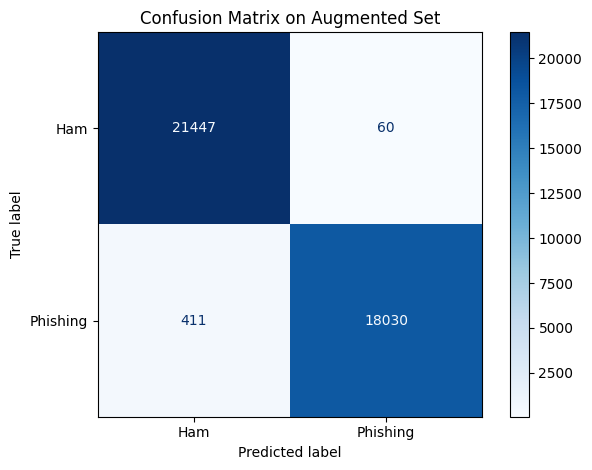

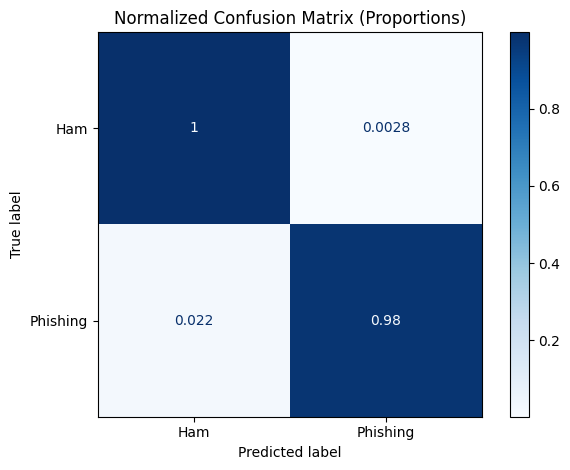

In [13]:

po = trainer.predict(test_dataset)
logits = po.predictions
labels = po.label_ids
preds = np.argmax(logits, axis=-1)

results = {"eval_samples": int(len(labels))}

report = classification_report(labels, preds,
                               target_names=["Ham", "Phishing"],
                               output_dict=True)
results.update(report)

with open("test_results_augmented.json", "w") as f:
    json.dump(results, f, indent=2)

label_order = [0, 1]
disp_names = ["Ham", "Phishing"]

cm = confusion_matrix(labels, preds, labels=label_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=disp_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Augmented Set")
plt.tight_layout()
plt.savefig("confusion_matrix_raw_augmented.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()

cm_norm = confusion_matrix(labels, preds, labels=label_order, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=disp_names)
disp.plot(cmap="Blues")
plt.title("Normalized Confusion Matrix (Proportions)")
plt.tight_layout()
plt.savefig("confusion_matrix_normalized_augmented.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close()


### 17. Error analysis for augmented train/val/test splits

Identify FP/FN cases and low-confidence samples and save detailed reports.


In [14]:
id2label = {0: "Ham", 1: "Phishing"}

ERROR_DIR = ANALYSIS_DIR / "error_analysis"
ERROR_DIR.mkdir(parents=True, exist_ok=True)

# Convert raw logits to probabilities using softmax
def _softmax(a):
    t = torch.tensor(a)
    return torch.softmax(t, dim=1).cpu().numpy()

# Collect misclassified or low-confidence samples for analysis
def collect_errors(split_name, dataset, *, texts):
    po = trainer.predict(dataset)
    logits, labels = po.predictions, po.label_ids
    probs = _softmax(logits)
    preds = probs.argmax(axis=1)

    assert len(texts) == len(labels), f"Length mismatch for {split_name}"
    text_series = pd.Series(list(map(str, texts)), dtype=str)

    df = pd.DataFrame(
        {
            "text": text_series,
            "true_label": labels,
            "pred_label": preds,
            "prob_ham": probs[:, 0],
            "prob_phishing": probs[:, 1],
        }
    )

    df["true_name"] = df["true_label"].map(id2label)
    df["pred_name"] = df["pred_label"].map(id2label)
    df["confidence"] = df[["prob_ham", "prob_phishing"]].max(axis=1)
    df["error_type"] = ""

    df.loc[(df.true_label == 0) & (df.pred_label == 1), "error_type"] = "FP"
    df.loc[(df.true_label == 1) & (df.pred_label == 0), "error_type"] = "FN"
    df["split"] = split_name

    errs = df[df["error_type"].isin(["FP", "FN"])].copy()
    errs.to_csv(ERROR_DIR / f"errors_{split_name}.csv", index=False)

    df.sort_values("confidence").to_csv(
        ERROR_DIR / f"hard_examples_{split_name}.csv",
        index=False,
    )

    print(
        f"[{split_name}] False Positives = {(errs.error_type=='FP').sum()} | False Negatives = {(errs.error_type=='FN').sum()}"
    )
    return errs

errs_train = collect_errors("train", train_dataset_aug, texts=augmented_train_texts)
errs_val = collect_errors("val", val_dataset, texts=val_texts)
errs_test = collect_errors("test", test_dataset, texts=test_texts)

pd.concat([errs_train, errs_val, errs_test], ignore_index=True).to_csv(
    ERROR_DIR / "errors_all_splits.csv", index=False
)


[train] False Positives = 24 | False Negatives = 403


[val] False Positives = 30 | False Negatives = 152


[test] False Positives = 60 | False Negatives = 411
